Exploratory Data Analysis (EDA) - Neural Retail Project

This notebook performs exploratory data analysis on the M5 forecasting dataset.

Objectives:

* Understand data structure
* Check data quality
* Analyze sales patterns
* Identify important features for modeling


Data Loading

We load the sales, calendar, and price datasets required for analysis.

In [1]:
import pandas as pd
import numpy as np

In [2]:
sales = pd.read_csv("../data/m5-forecasting-accuracy/sales_train_validation.csv", nrows=1000)
calendar = pd.read_csv("../data/m5-forecasting-accuracy/calendar.csv")
prices = pd.read_csv("../data/m5-forecasting-accuracy/sell_prices.csv")

Data Overview

We explore the structure and dimensions of each dataset.

In [3]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [4]:
sales.shape

(1000, 1919)

In [5]:
sales.columns[:10]

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1',
       'd_2', 'd_3', 'd_4'],
      dtype='object')

In [6]:
sales.isnull().sum().head()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
dtype: int64

In [7]:
sales.describe()

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.84900,0.771000,0.643000,0.602000,0.427000,0.693000,0.565000,1.178000,0.7150,0.575000,...,0.932000,1.493000,1.472000,1.11300,1.004000,0.884000,0.883000,1.089000,1.403000,1.504000
std,3.37455,3.443605,3.128472,2.308013,1.699282,3.358278,1.948222,4.603423,2.5769,2.538665,...,1.993326,3.451937,3.273826,2.65052,2.041115,1.960711,1.985259,2.128288,2.515337,2.928577
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,1.000000,2.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000
max,54.00000,73.000000,67.000000,33.000000,29.000000,74.000000,26.000000,78.000000,30.0000,36.000000,...,22.000000,49.000000,44.000000,37.00000,28.000000,28.000000,24.000000,20.000000,23.000000,35.000000


<Axes: title={'center': 'Sales Trend for One Product'}>

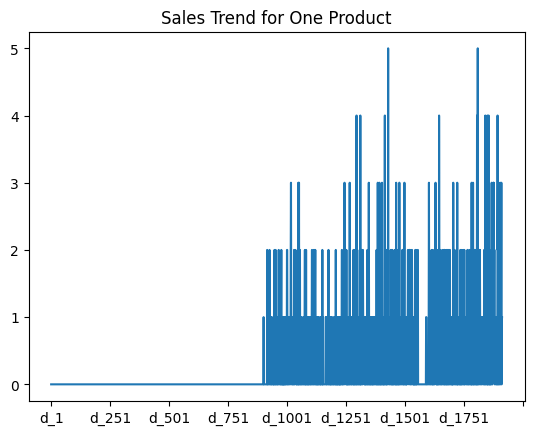

In [8]:
item = sales.iloc[0, 6:]   # skip metadata columns
item.plot(title="Sales Trend for One Product")

 Data Cleaning

Handling missing values and correcting data types.


In [9]:
calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [10]:
calendar[['date','event_name_1']].head()

,date,event_name_1
0,2011-01-29,NaN
1,2011-01-30,NaN
2,2011-01-31,NaN
3,2011-02-01,NaN
4,2011-02-02,NaN


In [11]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [12]:
prices.describe()

,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02


In [13]:
sales.isnull().sum()
calendar.isnull().sum()
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [14]:
sales.dtypes
calendar.dtypes
prices.dtypes

store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object

In [15]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [16]:
sales.duplicated().sum()

np.int64(0)

Observations:

* Calendar missing values replaced with "None"
* Prices missing values filled using forward/backward fill
* Sales missing values replaced with 0
* No duplicate records found


In [17]:
def load_data():
    sales = pd.read_csv("../data/m5-forecasting-accuracy/sales_train_validation.csv", nrows=1000)
    calendar = pd.read_csv("../data/m5-forecasting-accuracy/calendar.csv")
    prices = pd.read_csv("../data/m5-forecasting-accuracy/sell_prices.csv")
    return sales, calendar, prices

In [18]:
sales.isnull().sum().head()
calendar.isnull().sum().head()
prices.isnull().sum().head()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [19]:
calendar.fillna("None", inplace=True)

In [20]:
prices.ffill(inplace=True)

In [21]:
prices.bfill(inplace=True)

In [22]:
sales.fillna(0, inplace=True)

In [23]:
sales.dtypes
calendar.dtypes
prices.dtypes

store_id       object
item_id        object
wm_yr_wk        int64
sell_price    float64
dtype: object

In [24]:
calendar['date'] = pd.to_datetime(calendar['date'])

In [25]:
sales.duplicated().sum()
calendar.duplicated().sum()
prices.duplicated().sum()

np.int64(0)

In [26]:
sales.drop_duplicates(inplace=True)
calendar.drop_duplicates(inplace=True)
prices.drop_duplicates(inplace=True)

In [27]:
sales.shape
calendar.shape
prices.shape

(6841121, 4)

In [35]:
import sys
sys.path.append("../src")

In [36]:
from pipeline import run_pipeline

df = run_pipeline()

df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,week,lag_7,lag_28,rolling_mean_7,rolling_mean_28
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,None,0,0,0,NaN,4,NaN,NaN,NaN,NaN
1000,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0,2011-01-30,11101,...,None,0,0,0,NaN,4,NaN,NaN,NaN,NaN
2000,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,2011-01-31,11101,...,None,0,0,0,NaN,5,NaN,NaN,NaN,NaN
3000,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,2011-02-01,11101,...,None,1,1,0,NaN,5,NaN,NaN,NaN,NaN
4000,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,2011-02-02,11101,...,None,1,0,1,NaN,5,NaN,NaN,NaN,NaN


In [38]:
df.columns

Index(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd',
       'sales', 'date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year',
       'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
       'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'week', 'lag_7',
       'lag_28', 'rolling_mean_7', 'rolling_mean_28'],
      dtype='object')

In [40]:
df = run_pipeline()

In [41]:
sales.shape
calendar.shape
prices.shape

(6841121, 4)

In [42]:
calendar.isnull().sum()
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

Sales Distribution

We analyze how sales values are distributed across products.


<Axes: title={'center': 'Sales Trend (One Product)'}>

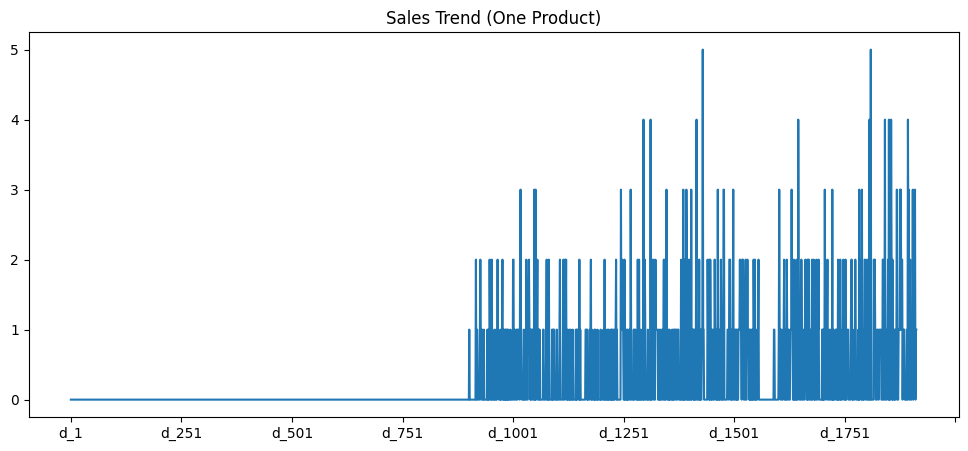

In [43]:
sales.iloc[0, 6:].plot(figsize=(12,5), title="Sales Trend (One Product)")

Insights:

* Most sales values are low (0–5 range)
* Data is highly skewed
* Few products contribute to high sales

This indicates a long-tail distribution typical in retail.


 Total Sales Over Time

We analyze how total sales change over time.


<Axes: title={'center': 'Total Sales Over Time'}>

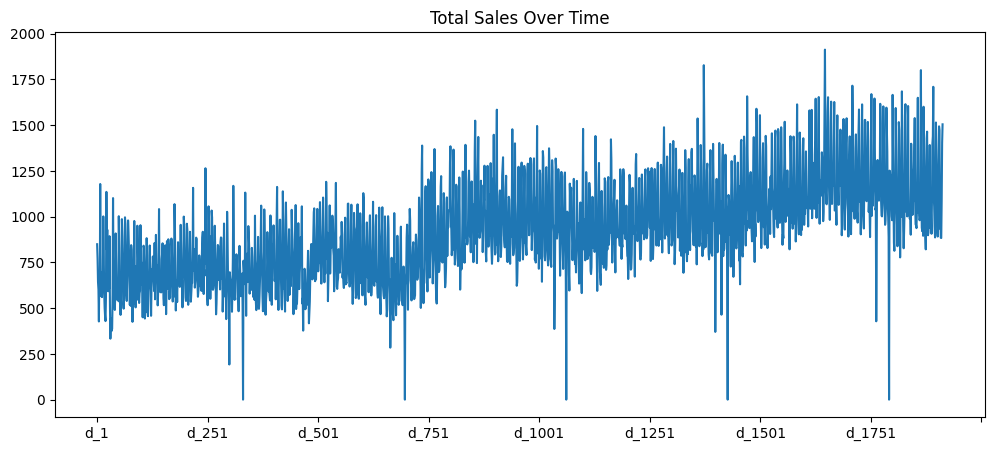

In [44]:
sales.iloc[:, 6:].sum().plot(figsize=(12,5), title="Total Sales Over Time")

Insights:

* Sales show an increasing trend over time
* Presence of spikes indicates events or promotions
* Sudden drops may indicate stockouts or anomalies

Time-based features will be important for modeling.


<Axes: >

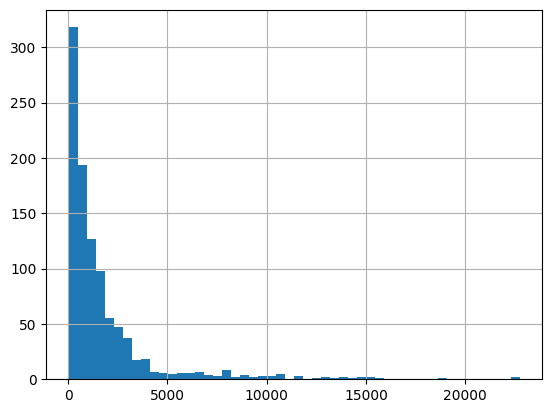

In [45]:
sales.iloc[:, 6:].sum(axis=1).hist(bins=50)

 Sales Trend (Single Product)

We analyze the behavior of one product over time.


<Axes: xlabel='weekday'>

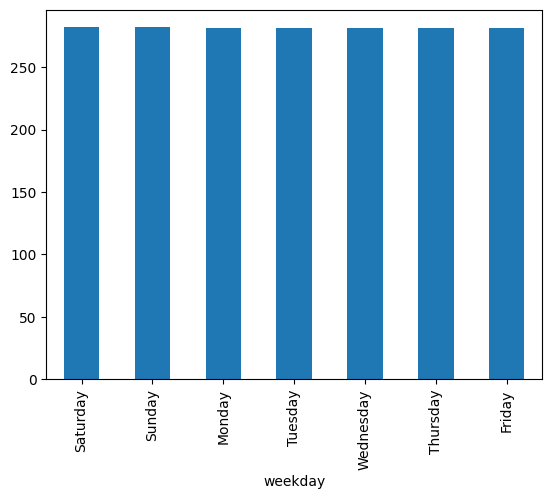

In [46]:
calendar['weekday'].value_counts().plot(kind='bar')

Insights:

* Many initial zero sales values
* Sales increase over time
* Different products behave differently

Model must capture product-level variation.


Weekday Analysis

We analyze sales distribution across different weekdays.


In [47]:
calendar['event_name_1'].value_counts().head(10)

event_name_1
None             1807
SuperBowl           6
ValentinesDay       6
PresidentsDay       6
LentStart           6
LentWeek2           6
StPatricksDay       6
Purim End           6
Pesach End          6
MemorialDay         6
Name: count, dtype: int64

Insights:

* Most days have no events
* Few special events (e.g., Super Bowl, Valentine’s Day)
* Events are rare but can strongly influence sales

Event-based features are important for forecasting.


 Price Distribution

We analyze how product prices are distributed.


<Axes: >

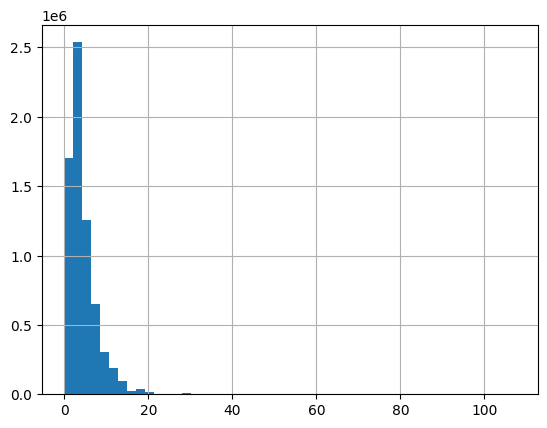

In [48]:
prices['sell_price'].hist(bins=50)

Insights:

* Most products are low-priced
* Few high-priced outliers exist
* Pricing varies across categories

Price is an important feature for demand prediction.


 Final Summary

* Data is clean and well-structured
* Sales data is highly skewed
* Strong time dependency observed
* Events influence sales spikes
* Product behavior varies significantly
* Price plays an important role

This dataset is suitable for time-series forecasting models.
